输出目录: results_amc_validation/

Step 1: 加载GME模型
✓ 模型加载完成
✓ 特征数: 102

Step 2: Fit scaler on GME raw data
✓ Scaler fitted on 59,146 GME bars
  特征数: 102

Step 3: 加载AMC数据
AMC数据维度: (67510, 113)
时间范围: 2019-07-01 12:30:00 ~ 2021-07-01 00:00:00
正样本: 2820 (4.18%)
✓ AMC数据标准化完成（使用GME scaler）

Step 4: 预测 (External Validation)

  AMC External Validation Results:
  ─────────────────────────────────────────────
  PR-AUC:       0.3411  (random baseline: 0.0418)
  ROC-AUC:      0.7191
  Improvement:  8.2× over random baseline
  Best threshold: 0.69

              precision    recall  f1-score   support

           0      0.971     0.943     0.957     64690
           1      0.210     0.348     0.262      2820

    accuracy                          0.918     67510
   macro avg      0.590     0.645     0.609     67510
weighted avg      0.939     0.918     0.928     67510


Step 5: 保存结果
✓ results_amc_validation/amc_validation_summary.csv


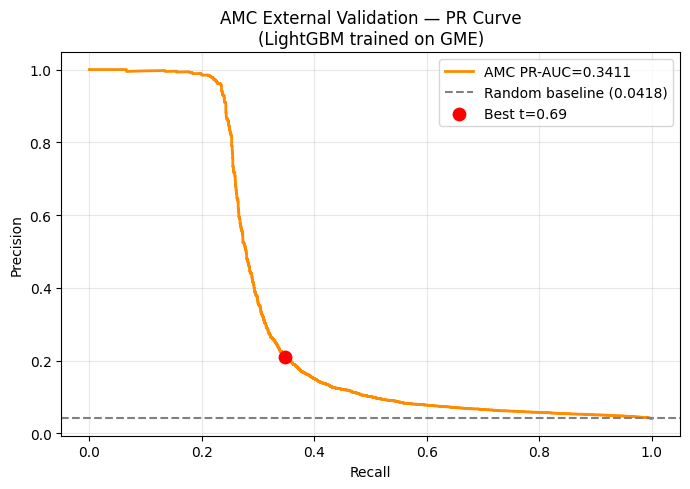

✓ results_amc_validation/amc_validation_pr_curve.png
✓ results_amc_validation/amc_daily_prediction.csv

AMC EXTERNAL VALIDATION COMPLETE

  PR-AUC:  0.3411 (8.2× vs random)
  ROC-AUC: 0.7191


In [4]:
import pandas as pd
import numpy as np
import json
import os
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score,
    classification_report, precision_recall_curve
)

# ── 配置 ──────────────────────────────────────────────────────────────────────
MODEL_FILE      = 'data/lgb_full_model.pkl'
FEATURES_FILE   = 'data/lgb_full_features.csv'
GME_RAW_FILE    = 'data/merged_data_raw_CLEAN.parquet'
AMC_RAW_FILE    = 'data/merged_data_amc_raw_CLEAN.parquet'

TARGET = 'EWS_15min'

LEAKAGE_FEATURES = [
    'is_episode_t', 'is_luld', 'is_anomaly',
    'is_price_spike', 'is_volume_surge',
    'thread_concentration', 'is_official_halt',
]

OUT_DIR = 'results_amc_validation'
os.makedirs(OUT_DIR, exist_ok=True)
print(f'输出目录: {OUT_DIR}/')

# ── 1. 加载GME训练好的模型和特征列表 ─────────────────────────────────────────
print('\n' + '='*65)
print('Step 1: 加载GME模型')
print('='*65)

model = joblib.load(MODEL_FILE)
gme_features = pd.read_csv(FEATURES_FILE)['feature'].tolist()
print(f'✓ 模型加载完成')
print(f'✓ 特征数: {len(gme_features)}')

# ── 2. 用GME raw数据fit scaler（与Merge脚本一致）────────────────────────────
print('\n' + '='*65)
print('Step 2: Fit scaler on GME raw data')
print('='*65)

gme_raw = pd.read_parquet(GME_RAW_FILE)
gme_raw['timestamp'] = pd.to_datetime(gme_raw['timestamp'])

fit_features = [f for f in gme_features if f in gme_raw.columns]
scaler = StandardScaler()
scaler.fit(gme_raw[fit_features].fillna(0))
print(f'✓ Scaler fitted on {len(gme_raw):,} GME bars')
print(f'  特征数: {len(fit_features)}')

# ── 3. 加载AMC数据并标准化 ────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 3: 加载AMC数据')
print('='*65)

amc_df = pd.read_parquet(AMC_RAW_FILE)
amc_df['timestamp'] = pd.to_datetime(amc_df['timestamp'])
amc_df = amc_df.sort_values('timestamp').reset_index(drop=True)

print(f'AMC数据维度: {amc_df.shape}')
print(f'时间范围: {amc_df["timestamp"].min()} ~ {amc_df["timestamp"].max()}')
print(f'正样本: {int(amc_df[TARGET].sum())} ({amc_df[TARGET].mean()*100:.2f}%)')

# 特征对齐：GME有但AMC没有的填0
X_amc_raw = pd.DataFrame(index=amc_df.index)
for feat in gme_features:
    if feat in amc_df.columns:
        X_amc_raw[feat] = amc_df[feat].fillna(0)
    else:
        X_amc_raw[feat] = 0

missing = [f for f in gme_features if f not in amc_df.columns]
if missing:
    print(f'⚠ AMC缺失特征（填0）: {len(missing)}个')
    print(f'  {missing}')

# 用GME scaler标准化AMC数据
X_amc_scaled = pd.DataFrame(
    scaler.transform(X_amc_raw[fit_features]),
    columns=fit_features,
    index=amc_df.index
)
# 补充scaler没见过的特征（直接用原始值）
for feat in gme_features:
    if feat not in fit_features:
        X_amc_scaled[feat] = X_amc_raw[feat]
X_amc = X_amc_scaled[gme_features]
print(f'✓ AMC数据标准化完成（使用GME scaler）')

# ── 4. 预测 ───────────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 4: 预测 (External Validation)')
print('='*65)

y_amc  = amc_df[TARGET]
y_prob = model.predict_proba(X_amc)[:, 1]

pr_auc  = average_precision_score(y_amc, y_prob)
roc_auc = roc_auc_score(y_amc, y_prob)
random_baseline = y_amc.mean()

thresholds = np.arange(0.02, 0.70, 0.01)
f1s    = [f1_score(y_amc, (y_prob >= t).astype(int), zero_division=0)
          for t in thresholds]
best_t = thresholds[np.argmax(f1s)]
y_pred = (y_prob >= best_t).astype(int)

print(f'\n  AMC External Validation Results:')
print(f'  {"─"*45}')
print(f'  PR-AUC:       {pr_auc:.4f}  (random baseline: {random_baseline:.4f})')
print(f'  ROC-AUC:      {roc_auc:.4f}')
print(f'  Improvement:  {pr_auc/random_baseline:.1f}× over random baseline')
print(f'  Best threshold: {best_t:.2f}')
print(f'\n{classification_report(y_amc, y_pred, digits=3, zero_division=0)}')

# ── 5. 保存结果 ───────────────────────────────────────────────────────────────
print('\n' + '='*65)
print('Step 5: 保存结果')
print('='*65)

summary = pd.DataFrame([{
    'dataset':                 'AMC (External Validation)',
    'model':                   'LightGBM (trained on GME)',
    'features':                'full_with_coordination',
    'n_features':              len(gme_features),
    'pr_auc':                  round(pr_auc, 4),
    'roc_auc':                 round(roc_auc, 4),
    'random_baseline':         round(random_baseline, 4),
    'improvement_vs_baseline': round(pr_auc / random_baseline, 2),
    'best_threshold':          round(best_t, 2),
    'f1_at_best_t':            round(f1_score(y_amc, y_pred, zero_division=0), 4),
    'precision':               round(precision_score(y_amc, y_pred, zero_division=0), 4),
    'recall':                  round(recall_score(y_amc, y_pred, zero_division=0), 4),
}])

summary.to_csv(f'{OUT_DIR}/amc_validation_summary.csv', index=False)
print(f'✓ {OUT_DIR}/amc_validation_summary.csv')

# PR曲线图
fig, ax = plt.subplots(figsize=(7, 5))
prec, rec, _ = precision_recall_curve(y_amc, y_prob)
ax.plot(rec, prec, color='darkorange', lw=2,
        label=f'AMC PR-AUC={pr_auc:.4f}')
ax.axhline(y=random_baseline, color='gray', linestyle='--',
           label=f'Random baseline ({random_baseline:.4f})')
ax.scatter(recall_score(y_amc, y_pred, zero_division=0),
           precision_score(y_amc, y_pred, zero_division=0),
           color='red', s=80, zorder=5, label=f'Best t={best_t:.2f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('AMC External Validation — PR Curve\n(LightGBM trained on GME)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/amc_validation_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ {OUT_DIR}/amc_validation_pr_curve.png')

# 每日预测
result_df = amc_df[['timestamp', TARGET]].copy()
result_df['prob'] = y_prob
result_df['pred'] = y_pred
result_df['date'] = result_df['timestamp'].dt.date
daily = result_df.groupby('date').agg(
    true_events=(TARGET, 'sum'),
    predicted=('pred', 'sum'),
    max_prob=('prob', 'max'),
)
daily.to_csv(f'{OUT_DIR}/amc_daily_prediction.csv')
print(f'✓ {OUT_DIR}/amc_daily_prediction.csv')

print('\n' + '='*65)
print('AMC EXTERNAL VALIDATION COMPLETE')
print('='*65)
print(f'\n  PR-AUC:  {pr_auc:.4f} ({pr_auc/random_baseline:.1f}× vs random)')
print(f'  ROC-AUC: {roc_auc:.4f}')